# Spectral decomposition closure 


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import add_mask_inside_swot, build_swath_polygon
from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, compute_variance, put_fig_letter

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [3]:
DT = 3
distance_to_coast_max = 20e3

In [4]:
band = ['', 'LF','diurnal', 'inertial', 'semidiurnal', 'HF']

# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = 'spectral_decomp',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list =[update_dict(base_dic, {'drifter_preprocess_param':b}) for b in band]


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0 = ds0.where(ds0.depth==0, drop=True)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds0 = ds0.where(ds0.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds0 = ds0.where((abs(ds0.ggde)<1e-4) & (abs(ds0.ggdn)<1e-4), drop=True)
ds0 = ds0.where(ds0.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
df0 = ds0.to_dataframe().reset_index().set_index('row_number')

#DEPTH 15M
base_dic = update_dict(base_dic, {'wd_depth':'15'})

comb_list = [update_dict(base_dic, {'drifter_preprocess_param':b}) for b in band]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15 =ds15.where(ds15.depth==15, drop=True)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)
ds15 = ds15.where(ds15.time_to_swot/pd.Timedelta('1h')<DT, drop=True)
#ds15 = ds15.where((abs(ds15.ggde)<1e-4) & (abs(ds15.ggdn)<1e-4), drop=True)
ds15 = ds15.where(ds15.distance_to_coast>distance_to_coast_max, drop=True)

# Correct mean geostrophic
df15 = ds15.to_dataframe().reset_index().set_index('row_number')

12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__inertial__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__semidiurnal__swot2km_fromduacsv__fromduacsv__era5_rio0
12h_spectral_decomp_all_med_variational_10min_v1__HF__swot2km_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__LF__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__diurnal__swot2km_fromduacsv__fromduacsv__era5_rio15
12h_spectral_decomp_all_med_variational_10min_v1__inertia

In [107]:
df0 = ds0.to_dataframe().reset_index().set_index('row_number')
df15 = ds15.to_dataframe().reset_index().set_index('row_number')

In [108]:
ds0['id_comb'] = ['all'] + band[1:]
ds15['id_comb'] = ['all'] + band[1:]

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS = DS.where((abs(DS.sel(id_comb='HF').acce)<5e-5)&(abs(DS.sel(id_comb='HF').accn)<5e-5))

ds = (compute_variance(DS, compute_error='centrallimit')/U2).rename({'id_comb':'Frequency band'})

df = ds.to_dataframe().reset_index()
df['Frequency band'] = ['All', 'LF', 'Inertial', 'Diurnal', 'Semidiurnal', 'HF']
df = df.set_index('Frequency band')

DS0 = ds0.where(ds0.depth==0, drop=True)
DS0 = DS0.where(DS0.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')
DS0 = DS0.where(DS0.distance_to_coast>distance_to_coast_max, drop=True)
DS0 = DS0.where((abs(DS0.sel(id_comb='HF').acce)<5e-5)&(abs(DS0.sel(id_comb='HF').accn)<5e-5))# outliers
ds0_ = (compute_variance(DS0, compute_error='centrallimit')/U2).rename({'id_comb':'Frequency band'})
df0 = ds0_.to_dataframe().reset_index()
df0['Frequency band'] = ['All', 'LF', 'Inertial', 'Diurnal', 'Semidiurnal', 'HF']
df0 = df0.set_index('Frequency band')


DS15 = ds15.where(ds15.depth==15, drop=True)
DS15 = DS15.where(DS15.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')
DS15 = DS15.where(DS15.distance_to_coast>distance_to_coast_max, drop=True)
DS15 = DS15.where((abs(DS15.sel(id_comb='HF').acce)<5e-5)&(abs(DS15.sel(id_comb='HF').accn)<5e-5))# outliers
ds15_ = (compute_variance(DS15, compute_error='centrallimit')/U2).rename({'id_comb':'Frequency band'})
df15 = ds15_.to_dataframe().reset_index()
df15['Frequency band'] = ['All', 'LF', 'Inertial', 'Diurnal', 'Semidiurnal', 'HF']
df15 = df15.set_index('Frequency band')



2211
1267
944


# Errors

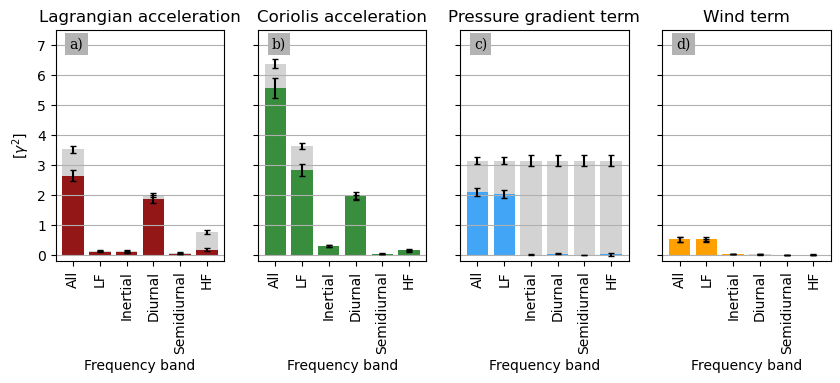

In [6]:
vars = ['acc', 'cor', 'ggd','wd']
title={'acc' : 'Lagrangian acceleration', 'cor':'Coriolis acceleration', 'ggd':'Pressure gradient term','wd':'Wind term'}
plt.rcParams["axes.edgecolor"] = "k"

kwargs = dict(width=0.8, capsize=2)
fig, axs = plt.subplots(1, 4, figsize = (10, 3), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()
for j in range(len(vars)): 
    ax=axs[j]
    df['E_'+vars[j]].plot.bar(ax=ax, color= 'lightgrey', bottom = df['B_'+vars[j]], yerr =df['er__E_'+vars[j]], **kwargs)
    df['B_'+vars[j]].plot.bar(ax=ax, color= c0[vars[j]], yerr =df['er__B_'+vars[j]], **kwargs)
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_title(title[vars[j]])
    ax.set_ylim(-0.2, 7.5)

i=0
for l in ['a', 'b', 'c', 'd'] :
    put_fig_letter(fig, axs[i], l)
    i+=1
    

# Paired contributions

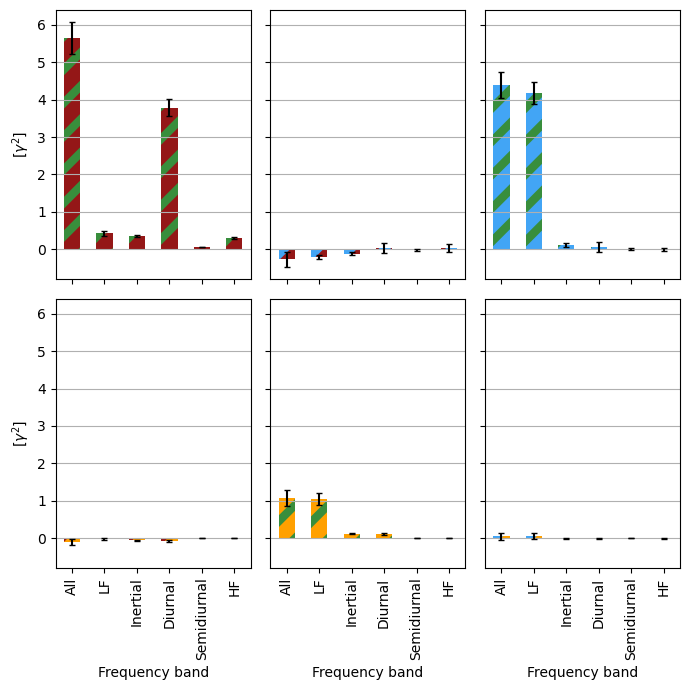

In [28]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 3, figsize = (7, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

ax=axs[0]
plt.rcParams["hatch.color"] = c0['cor']
df.X_acc_cor.plot.bar(color = c0['acc'], hatch="/", ax=ax, yerr =df['er__X_acc_cor'], capsize=2)

ax=axs[1]
plt.rcParams["hatch.color"] = c0['ggd']
df.X_acc_ggd.plot.bar(color = c0['acc'], hatch="/", ax=ax, yerr =df['er__X_acc_ggd'], capsize=2)

ax=axs[2]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_ggd.plot.bar(color = c0['ggd'], hatch="/", ax=ax, yerr =df['er__X_cor_ggd'], capsize=2)

ax=axs[3]
plt.rcParams["hatch.color"] = c0['acc']
df.X_acc_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df['er__X_acc_wd'], capsize=2)

ax=axs[4]
plt.rcParams["hatch.color"] = c0['cor']
df.X_cor_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df['er__X_cor_wd'], capsize=2)

ax=axs[5]
plt.rcParams["hatch.color"] = c0['ggd']
df.X_ggd_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df['er__X_ggd_wd'], capsize=2)

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')

fig.tight_layout()

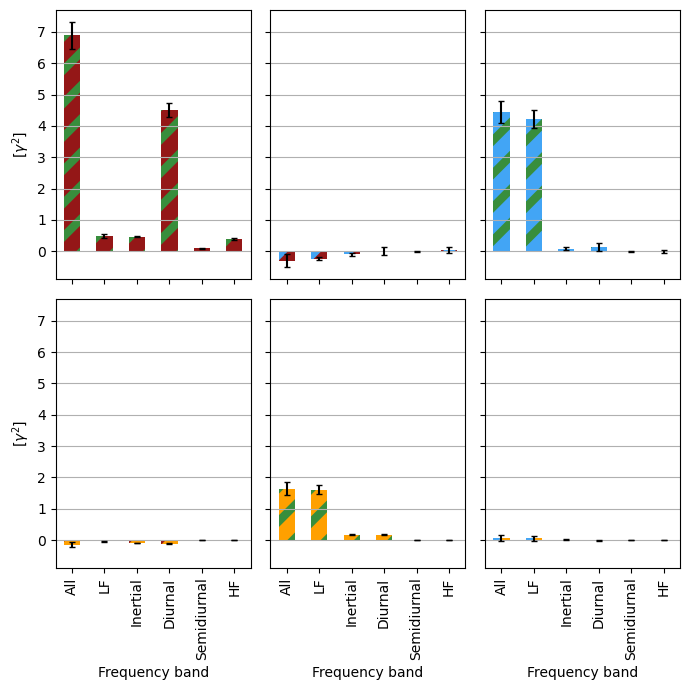

In [7]:
plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6
fig, axs = plt.subplots(2, 3, figsize = (7, 7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

ax=axs[0]
plt.rcParams["hatch.color"] = c0['cor']
df0.X_acc_cor.plot.bar(color = c0['acc'], hatch="/", ax=ax, yerr =df0['er__X_acc_cor'], capsize=2)

ax=axs[1]
plt.rcParams["hatch.color"] = c0['ggd']
df0.X_acc_ggd.plot.bar(color = c0['acc'], hatch="/", ax=ax, yerr =df0['er__X_acc_ggd'], capsize=2)

ax=axs[2]
plt.rcParams["hatch.color"] = c0['cor']
df0.X_cor_ggd.plot.bar(color = c0['ggd'], hatch="/", ax=ax, yerr =df0['er__X_cor_ggd'], capsize=2)

ax=axs[3]
plt.rcParams["hatch.color"] = c0['acc']
df0.X_acc_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df0['er__X_acc_wd'], capsize=2)

ax=axs[4]
plt.rcParams["hatch.color"] = c0['cor']
df0.X_cor_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df0['er__X_cor_wd'], capsize=2)

ax=axs[5]
plt.rcParams["hatch.color"] = c0['ggd']
df0.X_ggd_wd.plot.bar(color = c0['wd'], hatch="/", ax=ax, yerr =df0['er__X_ggd_wd'], capsize=2)

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')

fig.tight_layout()

/dev/shm/pbs.3586268.datarmor0/ipykernel_29501/2485445272.py:57: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate('Surface',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
/dev/shm/pbs.3586268.datarmor0/ipykernel_29501/2485445272.py:58: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate('15m',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)


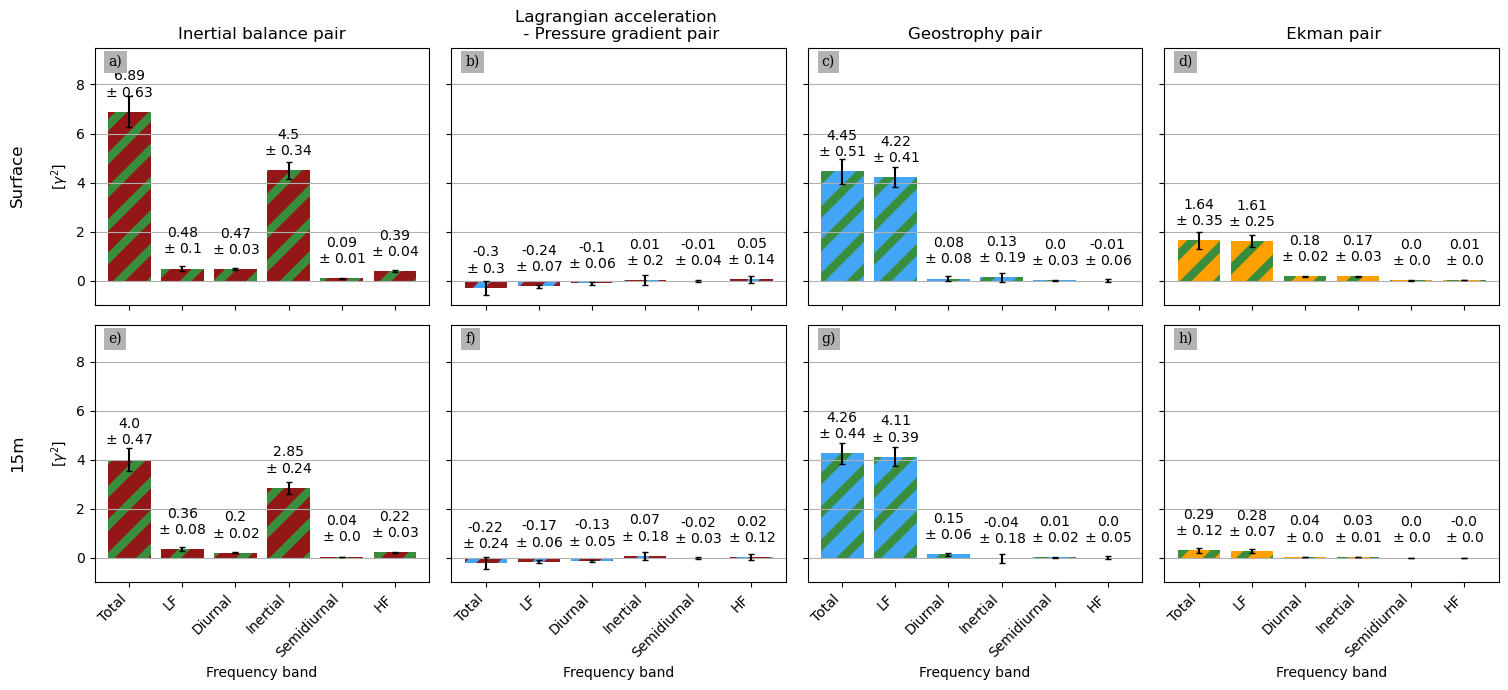

In [127]:
def print_labels(df, X, ax):
    for i in range(0, 6):
        #SX = df.iloc[i][[v for v in df.columns if ('X_' in v)&('er__' not in v)]].sum()
        #SX = df.loc['All'].X_cor_ggd
        #erSX = df.loc['All'].er__X_cor_ggd
        
        label = rf"{np.round(df[X].iloc[i], 2)}"+'\n'+rf"$\pm$ {np.round(df['er__' + X].iloc[i], 2)}"
        #if i in [1,2, 3, 4] :
        #    label = label + '\n' + rf"{int(df[X].iloc[i]/SX*100)} $\pm$ {int(df[X].iloc[i]/SX*100*((df['er__'+X]/df[X]).iloc[i] + erSX/SX))}%"
        ax.text(i,
                df[X].iloc[i] + 0.5,
                label,
                horizontalalignment="center",
                verticalalignment="bottom",
                rotation = 0
            )

plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(2,4, figsize = (15,7), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/",width = 0.8, capsize=2)

def plot(df_, axs, init) : 
    ax=axs[init + 0]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_acc_cor.plot.bar(color = c0['acc'], ax=ax, yerr =df_['er__X_acc_cor'], **kwargs)
    print_labels(df_, 'X_acc_cor', ax)
    
    ax=axs[init + 1]
    plt.rcParams["hatch.color"] = c0['ggd']
    df_.X_acc_ggd.plot.bar(color = c0['acc'], ax=ax, yerr =df_['er__X_acc_ggd'], **kwargs)
    print_labels(df_, 'X_acc_ggd', ax)
    
    ax=axs[init + 2]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_cor_ggd.plot.bar(color = c0['ggd'],ax=ax, yerr =df_['er__X_cor_ggd'], **kwargs)
    print_labels(df_, 'X_cor_ggd', ax)
    
    
    ax=axs[init + 3]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_cor_wd.plot.bar(color = c0['wd'], ax=ax, yerr =df_['er__X_cor_wd'], **kwargs)
    print_labels(df_, 'X_cor_wd', ax)

plot(df0, axs,0)
plot(df15, axs, 4)

axs[0].set_title('Inertial balance pair')
axs[1].set_title('Lagrangian acceleration \n - Pressure gradient pair')
axs[2].set_title('Geostrophy pair')
axs[3].set_title(' Ekman pair')

pad=0
axs[0].annotate('Surface',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
axs[4].annotate('15m',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)

l = ['a', 'b', 'c', 'd', 'e','f','g', 'h']
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks([0, 1, 2, 3, 4, 5], ['Total', 'LF','Diurnal', 'Inertial', 'Semidiurnal', 'HF'], rotation=45, ha='right')

axs[0].set_ylim(-1, 9.5)

fig.tight_layout()

# Percentage of Balanced signal

In [115]:
for df in [df0, df15] :
    df['B'] = df[[v for v in df.columns if ('X_' in v)&('er__' not in v)]].sum(axis=1)
    df['er__B'] = df[[v for v in df.columns if ('er__X_' in v)]].sum(axis=1)
    for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)]:
        df[X+'B_percentage'] = df[X]/df['B']
        df['er__'+X+'B_percentage'] = df[X+'B_percentage'] * ((df['er__' + X]/df[X])+ (df['er__B']/df['B']))

In [126]:
df0[[X for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]

,X_acc_cor,X_acc_ggd,X_acc_wd,X_cor_ggd,X_cor_wd,X_ggd_wd
Frequency band,,,,,,
All,6.886594,-0.297678,-0.141652,4.453583,1.642917,0.073708
LF,0.482450,-0.236618,-0.035999,4.217747,1.614387,0.060215
Inertial,0.465598,-0.103442,-0.092380,0.082411,0.178518,0.017455
Diurnal,4.504013,0.009771,-0.123063,0.133865,0.166204,-0.012720
Semidiurnal,0.089107,-0.007112,-0.001259,0.001966,0.002389,0.002769
HF,0.388285,0.045290,-0.004159,-0.007216,0.010042,-0.000984


In [101]:
df0[['er__'+X for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]

,er__X_acc_cor,er__X_acc_ggd,er__X_acc_wd,er__X_cor_ggd,er__X_cor_wd,er__X_ggd_wd
Frequency band,,,,,,
All,0.634590,0.296140,0.142366,0.511870,0.347786,0.158450
LF,0.096952,0.072980,0.034537,0.414244,0.252689,0.141404
Inertial,0.029417,0.060564,0.007135,0.082616,0.015047,0.023928
Diurnal,0.342920,0.199629,0.027247,0.193905,0.028828,0.026389
Semidiurnal,0.006835,0.042219,0.001243,0.027712,0.000826,0.006294
HF,0.041065,0.144043,0.010890,0.059123,0.004991,0.018542


In [116]:
df0[[X+'B_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,X_acc_corB_percentage,X_acc_ggdB_percentage,X_acc_wdB_percentage,X_cor_ggdB_percentage,X_cor_wdB_percentage,X_ggd_wdB_percentage
Frequency band,,,,,,
All,54.579825,-2.359254,-1.122669,35.296959,13.020968,0.584171
LF,7.906193,-3.877600,-0.589937,69.118669,26.455895,0.986781
Inertial,84.938114,-18.870633,-16.852652,15.034139,32.566715,3.184318
Diurnal,96.279311,0.208858,-2.630636,2.861542,3.552831,-0.271905
Semidiurnal,101.419226,-8.094255,-1.433350,2.237513,2.718939,3.151927
HF,90.035473,10.501936,-0.964490,-1.673255,2.328459,-0.228124


In [103]:
df0[['er__' + X+'B_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,er__X_acc_corB_percentage,er__X_acc_ggdB_percentage,er__X_acc_wdB_percentage,er__X_cor_ggdB_percentage,er__X_cor_wdB_percentage,er__X_ggd_wdB_percentage
Frequency band,,,,,,
All,14.075448,1.956045,0.942256,9.906905,4.914465,1.352619
LF,2.901032,0.552384,0.468057,18.260404,8.531974,2.481056
Inertial,39.255376,3.519530,-5.422327,21.069832,15.738494,5.635557
Diurnal,24.184510,4.303897,0.121926,4.645913,1.238168,0.516509
Semidiurnal,106.045749,40.209691,0.025644,33.708631,3.574730,10.217121
HF,67.698049,40.186417,1.901935,12.628233,2.661880,4.152205


In [117]:
df15[[X+'B_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,X_acc_corB_percentage,X_acc_ggdB_percentage,X_acc_wdB_percentage,X_cor_ggdB_percentage,X_cor_wdB_percentage,X_ggd_wdB_percentage
Frequency band,,,,,,
All,47.925440,-2.585950,-0.421467,51.042034,3.532443,0.507500
LF,7.681179,-3.609185,-0.273529,88.811793,5.939846,1.449896
Inertial,95.595616,-60.474090,-12.374850,70.577639,18.034250,-11.358565
Diurnal,98.550586,2.524338,-0.859830,-1.311986,1.172025,-0.075133
Semidiurnal,104.213456,-46.382289,0.715621,32.517151,0.295535,8.640526
HF,88.666363,8.957628,1.700587,0.997976,-0.119029,-0.203525


In [118]:
df15[['er__' + X+'B_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,er__X_acc_corB_percentage,er__X_acc_ggdB_percentage,er__X_acc_wdB_percentage,er__X_cor_ggdB_percentage,er__X_cor_wdB_percentage,er__X_ggd_wdB_percentage
Frequency band,,,,,,
All,13.604273,2.421381,0.696728,13.769669,2.037855,0.659293
LF,2.757011,0.841166,0.203846,21.078080,2.365489,1.273372
Inertial,75.111149,-19.126772,-6.987706,75.573691,14.180450,-3.287818
Diurnal,29.548640,6.743628,0.077763,5.919089,0.538594,0.280932
Semidiurnal,169.998056,10.889312,1.802231,102.226047,0.922613,19.234455
HF,85.223672,56.029064,2.849850,21.521202,0.425352,2.459302


# Percentage of total variance

In [120]:
for df in [df0, df15] :
    for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]:
        df[X+'all_percentage'] = df[X]/df[X].loc['All']
        df['er__'+X+'all_percentage'] = df[X+'all_percentage'] * ((df['er__' + X]/df[X])+ (df['er__'+X]/df[X]).loc['All'])

In [121]:
df0[[X+'all_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,X_acc_corall_percentage,X_acc_ggdall_percentage,X_acc_wdall_percentage,X_cor_ggdall_percentage,X_cor_wdall_percentage,X_ggd_wdall_percentage
Frequency band,,,,,,
All,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
LF,7.005644,79.487932,25.413635,94.704558,98.263441,81.694625
Inertial,6.760935,34.749466,65.215790,1.850451,10.865932,23.681693
Diurnal,65.402630,-3.282240,86.876706,3.005780,10.116391,-17.257258
Semidiurnal,1.293914,2.389018,0.889032,0.044141,0.145403,3.757105
HF,5.638278,-15.214572,2.936370,-0.162028,0.611210,-1.334737


In [122]:
df0[['er__'+X+'all_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,er__X_acc_corall_percentage,er__X_acc_ggdall_percentage,er__X_acc_wdall_percentage,er__X_cor_ggdall_percentage,er__X_cor_wdall_percentage,er__X_ggd_wdall_percentage
Frequency band,,,,,,
All,18.429736,-198.966717,-201.007739,22.986871,42.337659,429.942518
LF,2.053394,-103.593710,-49.922931,20.186181,36.181757,367.465009
Inertial,1.050182,-54.915421,-70.581211,2.067727,3.216047,83.371757
Diurnal,11.006295,-63.796722,-106.549240,4.699385,3.896183,-1.295396
Semidiurnal,0.218489,-16.559295,-1.770808,0.627303,0.081067,16.615242
HF,1.115868,-33.252891,-10.638887,1.308913,0.433188,22.287402


In [123]:
df15[[X+'all_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,X_acc_corall_percentage,X_acc_ggdall_percentage,X_acc_wdall_percentage,X_cor_ggdall_percentage,X_cor_wdall_percentage,X_ggd_wdall_percentage
Frequency band,,,,,,
All,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
LF,8.896779,77.474720,36.025598,96.585888,93.340705,158.588640
Inertial,5.016575,58.814536,73.843508,3.477560,12.839805,-56.288967
Diurnal,71.409134,-33.899091,70.845191,-0.892610,11.521850,-5.141075
Semidiurnal,1.036107,8.546318,-0.809035,0.303551,0.039864,8.112441
HF,5.407695,-10.124937,-11.793838,0.057149,-0.098491,-1.172200


In [124]:
df15[['er__'+X+'all_percentage' for X in [v for v in df.columns if ('X_' in v)&('er__' not in v)&('percentage' not in v)]]]*100

,er__X_acc_corall_percentage,er__X_acc_ggdall_percentage,er__X_acc_wdall_percentage,er__X_cor_ggdall_percentage,er__X_cor_wdall_percentage,er__X_ggd_wdall_percentage
Frequency band,,,,,,
All,23.583458,-220.461225,-363.810020,20.765034,82.190163,226.630844
LF,2.973776,-114.504806,-97.517257,19.178539,62.220614,296.372046
Inertial,1.135350,-86.065700,-142.643141,1.729384,6.675960,-41.951966
Diurnal,14.439374,-45.885635,-150.548349,4.126776,7.546226,14.505733
Semidiurnal,0.231883,-24.463345,0.668262,0.522781,0.080024,14.877122
HF,1.279177,-43.638995,11.626234,1.190201,0.394467,13.823663


# Plot

/dev/shm/pbs.3586268.datarmor0/ipykernel_29501/273479520.py:54: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[0].annotate('Surface',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
/dev/shm/pbs.3586268.datarmor0/ipykernel_29501/273479520.py:55: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  axs[4].annotate('15m',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)


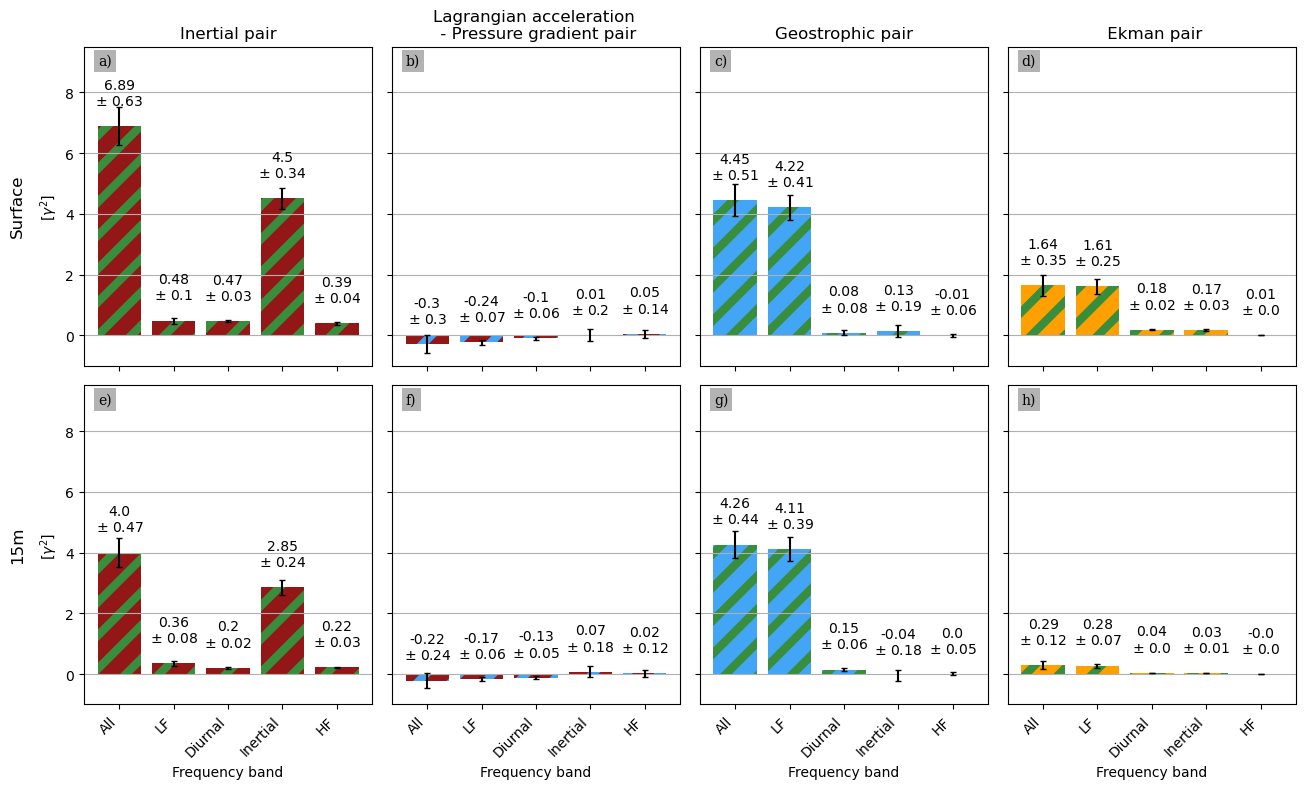

In [106]:
def print_labels(df, X, ax):
    for i in range(0, 5):
        #SX = df.iloc[i][[v for v in df.columns if ('B_' in v)&('er__' not in v)]].sum()
        label = rf"{np.round(df[X].iloc[i], 2)}"+'\n'+rf"$\pm$ {np.round(df['er__' + X].iloc[i], 2)}"
        #if i in [0, 1, 3] :
        #    label = label + '\n' + f"{int(df[X].iloc[i]/SX*100)}%"
        ax.text(i,
                df[X].iloc[i] + 0.6,
                label,
                horizontalalignment="center",
                verticalalignment="bottom",
                rotation = 0
            )

plt.rcParams["axes.edgecolor"] = "k"
plt.rcParams["hatch.linewidth"] = 6

fig, axs = plt.subplots(2,4, figsize = (13,8), frameon=False, sharex=True, sharey=True)
axs = axs.flatten()

kwargs = dict(hatch="/",width = 0.8, capsize=2)

def plot(df_, axs, init) : 
    ax=axs[init + 0]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_acc_cor.plot.bar(color = c0['acc'], ax=ax, yerr =df_['er__X_acc_cor'], **kwargs)
    print_labels(df_, 'X_acc_cor', ax)
    
    ax=axs[init + 1]
    plt.rcParams["hatch.color"] = c0['ggd']
    df_.X_acc_ggd.plot.bar(color = c0['acc'], ax=ax, yerr =df_['er__X_acc_ggd'], **kwargs)
    print_labels(df_, 'X_acc_ggd', ax)
    
    ax=axs[init + 2]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_cor_ggd.plot.bar(color = c0['ggd'],ax=ax, yerr =df_['er__X_cor_ggd'], **kwargs)
    print_labels(df_, 'X_cor_ggd', ax)
    
    
    ax=axs[init + 3]
    plt.rcParams["hatch.color"] = c0['cor']
    df_.X_cor_wd.plot.bar(color = c0['wd'], ax=ax, yerr =df_['er__X_cor_wd'], **kwargs)
    print_labels(df_, 'X_cor_wd', ax)

plot(df0.iloc[[0, 1, 2, 3, 5]], axs,0)
plot(df15.iloc[[0, 1, 2, 3, 5]], axs, 4)

axs[0].set_title('Inertial pair')
axs[1].set_title('Lagrangian acceleration \n - Pressure gradient pair')
axs[2].set_title('Geostrophic pair')
axs[3].set_title(' Ekman pair')

pad=0
axs[0].annotate('Surface',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)
axs[4].annotate('15m',xy = (-0.23, 0.5),  xycoords='axes fraction', textcoords='offset points',size='large', ha='center', va='center', rotation = 90)

l = ['a', 'b', 'c', 'd', 'e','f','g', 'h']
for i in range(len(axs)):
    put_fig_letter(fig, axs[i], l[i])

for ax in axs :
    ax.grid(axis = 'y')
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks([0, 1, 2, 3, 4], ['All', 'LF','Diurnal', 'Inertial', 'HF'], rotation=45, ha='right')

axs[0].set_ylim(-1, 9.5)

fig.tight_layout()

## Frequency bandm

In [22]:
def cpd_to_hours(x): return 24/x

In [23]:
cpd_to_hours(0.88), cpd_to_hours(1.05), cpd_to_hours(1.75), cpd_to_hours(1.9), cpd_to_hours(2.1)

(27.272727272727273,
 22.857142857142858,
 13.714285714285714,
 12.631578947368421,
 11.428571428571429)